# ClimateGuard AI v3.0 - Explainable AI (SHAP) 

This notebook covers model explanation using SHAP values. 

## 1. Import Libraries  

In [1]:
from pathlib import Path
import os
import sys
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

%matplotlib inline

project_root = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "data" / "processed").is_dir()
        and (candidate / "trained_models").is_dir()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not locate the project data and trained_models folders.")

sys.path.insert(0, str(project_root))
os.environ.setdefault("SHAP_USE_NUMBA", "0")
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

print(f"Project root: {project_root}")
print(f"SHAP version: {shap.__version__}")

Project root: d:\AI-Powered-Climate Risk Intelligence Platform
SHAP version: 0.52.0


## 2. Load Trained Model and Data 

In [2]:
processed_dir = project_root / "data" / "processed"
model_path = project_root / "trained_models" / "02_rainfall_model.pkl"
explanation_data_path = processed_dir / "11_anomaly_detection.csv"
training_data_path = processed_dir / "07_climate_zones.csv"

for required_path in (model_path, explanation_data_path, training_data_path):
    if not required_path.is_file():
        raise FileNotFoundError(f"Required input file not found: {required_path}")

rainfall_model = joblib.load(model_path)
df = pd.read_csv(explanation_data_path)
training_df = pd.read_csv(training_data_path)

print(f"Loaded model: {model_path.name} ({type(rainfall_model).__name__})")
print(f"Explanation data: {df.shape}")
print(f"Training data: {training_df.shape}")

Loaded model: 02_rainfall_model.pkl (DecisionTreeClassifier)
Explanation data: (119398, 103)
Training data: (119398, 84)


## 3. Prepare Features for Explanation

The input columns and scaling follow the rainfall training notebook exactly. The saved model includes `precip_mm`, the field used to derive the rainfall target; its explanations are therefore faithful to the saved model but reveal target leakage. Retrain the rainfall model without target-derived features before using it for predictive decisions.

In [3]:
if "precip_mm" not in training_df.columns:
    raise KeyError("Training data is missing the precipitation target column 'precip_mm'.")

feature_names = [
    column
    for column in training_df.select_dtypes(include=[np.number]).columns
    if column not in {"climate_zone", "rain_target"}
]
expected_features = getattr(rainfall_model, "n_features_in_", None)
if expected_features is not None and len(feature_names) != expected_features:
    raise ValueError(
        f"Training recipe produced {len(feature_names)} features; "
        f"the saved model expects {expected_features}."
    )

missing_features = [column for column in feature_names if column not in df.columns]
if missing_features:
    raise ValueError(f"Explanation data is missing model features: {missing_features}")

X_train_full = training_df[feature_names].replace([np.inf, -np.inf], np.nan).fillna(0)
y = (training_df["precip_mm"] > 0).astype(int)
X_train, _, _, _ = train_test_split(
    X_train_full,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)
scaler = StandardScaler().fit(X_train)

X_explain_df = (
    df[feature_names]
    .replace([np.inf, -np.inf], np.nan)
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .iloc[:100]
    .copy()
)
X_explain = scaler.transform(X_explain_df)

print(f"Model features aligned: {len(feature_names)}")
print(f"Samples selected for explanation: {len(X_explain_df)}")

Model features aligned: 62
Samples selected for explanation: 100


## 4. Initialize Tree SHAP Explainer

In [4]:
explainer = shap.TreeExplainer(rainfall_model)
print("Tree SHAP explainer initialized")

Tree SHAP explainer initialized


## 5. Calculate SHAP Values

In [5]:
shap_explanation = explainer(X_explain, check_additivity=False)
raw_shap_values = np.asarray(shap_explanation.values)

if raw_shap_values.ndim == 3:
    shap_values = raw_shap_values[:, :, 1]
elif raw_shap_values.ndim == 2:
    shap_values = raw_shap_values
else:
    raise ValueError(f"Unexpected SHAP output shape: {raw_shap_values.shape}")

if shap_values.shape != X_explain.shape:
    raise ValueError(
        f"SHAP output shape {shap_values.shape} does not match input {X_explain.shape}."
    )

base_values = np.asarray(shap_explanation.base_values)
if base_values.ndim == 2:
    base_values = base_values[:, 1]
elif base_values.ndim == 0:
    base_values = np.repeat(base_values, len(X_explain))
base_value = float(np.ravel(base_values)[0])

print(f"SHAP values calculated: {shap_values.shape}")
print(f"Class-1 base value: {base_value:.6f}")

SHAP values calculated: (100, 62)
Class-1 base value: 0.124689


## 6. Calculate Global Feature Importance

In [6]:
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
feature_importance_df = (
    pd.DataFrame(
        {"feature": feature_names, "mean_abs_shap": mean_abs_shap}
    )
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
feature_importance_df.insert(0, "rank", range(1, len(feature_importance_df) + 1))
feature_importance = dict(
    zip(feature_importance_df["feature"], feature_importance_df["mean_abs_shap"])
)

display(feature_importance_df.head(15))

,rank,feature,mean_abs_shap
0,1,precip_mm,0.259801
1,2,latitude,0.000000
2,3,last_updated_epoch,0.000000
3,4,temperature_celsius,0.000000
4,5,wind_kph,0.000000
5,6,longitude,0.000000
6,7,wind_degree,0.000000
7,8,pressure_mb,0.000000
8,9,humidity,0.000000
9,10,cloud,0.000000


## 7. SHAP Summary Plot

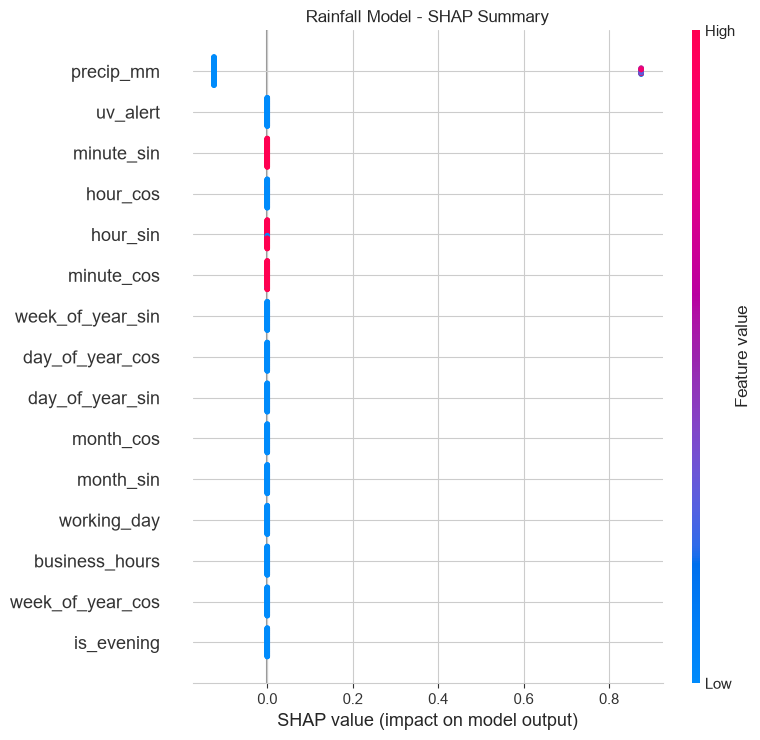

In [7]:
shap.summary_plot(
    shap_values,
    X_explain_df,
    max_display=15,
    show=False,
)
plt.title("Rainfall Model - SHAP Summary")
plt.tight_layout()
plt.show()

## 8. SHAP Bar Plot

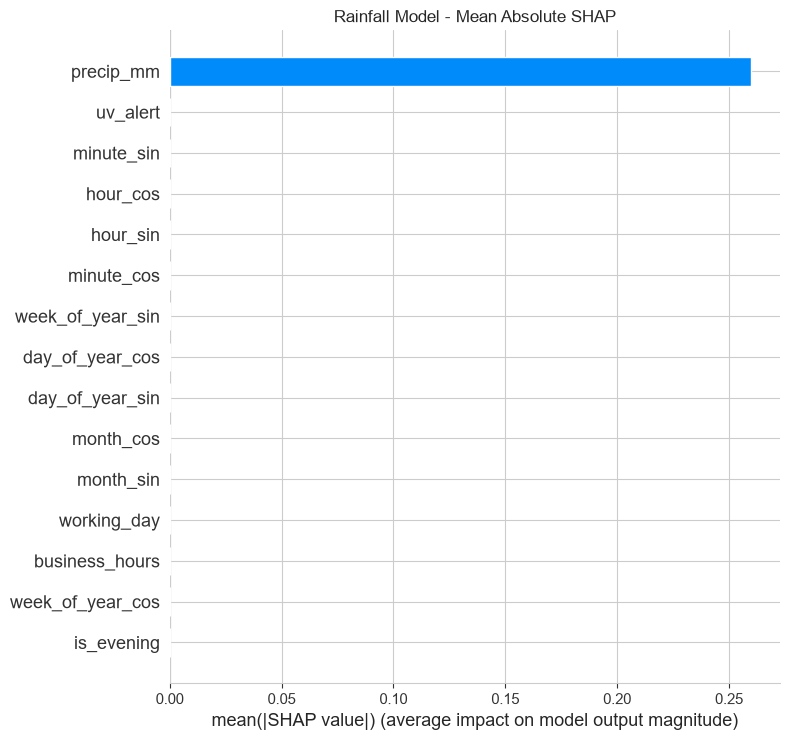

In [8]:
shap.summary_plot(
    shap_values,
    X_explain_df,
    plot_type="bar",
    max_display=15,
    show=False,
)
plt.title("Rainfall Model - Mean Absolute SHAP")
plt.tight_layout()
plt.show()

## 9. SHAP Waterfall Plot

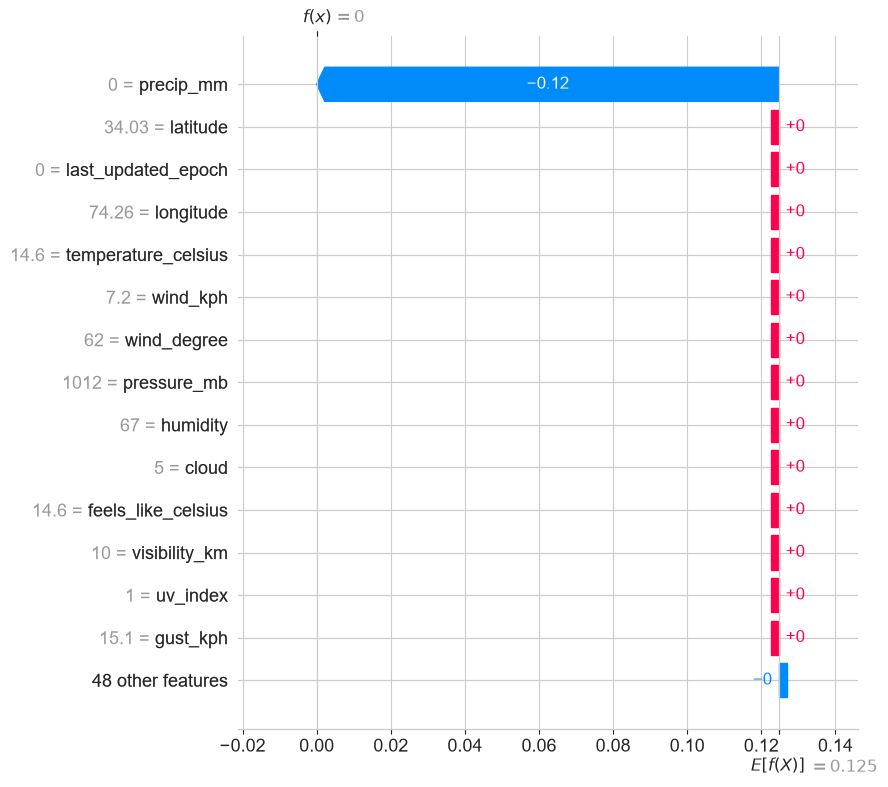

In [9]:
instance_idx = 0
instance_explanation = shap.Explanation(
    values=shap_values[instance_idx],
    base_values=base_value,
    data=X_explain_df.iloc[instance_idx].to_numpy(),
    feature_names=feature_names,
)
shap.plots.waterfall(instance_explanation, max_display=15)

## 10. SHAP Decision Plot

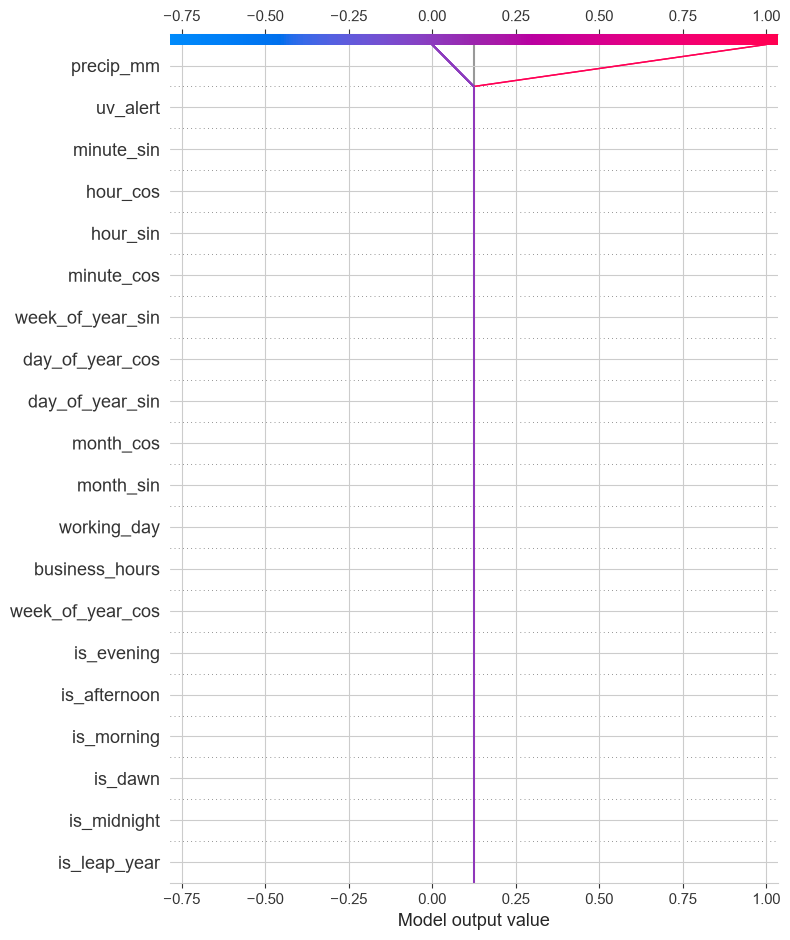

In [10]:
plt.figure(figsize=(14, 6))
shap.decision_plot(
    base_value,
    shap_values[:20],
    X_explain_df.iloc[:20],
    feature_names=feature_names,
    show=False,
)
plt.tight_layout()
plt.show()

## 11. Explain a Single Instance

In [11]:
instance_idx = 0
predicted_rain_probability = float(
    rainfall_model.predict_proba(X_explain[instance_idx : instance_idx + 1])[0, 1]
)
instance_contributions = (
    pd.DataFrame(
        {
            "feature": feature_names,
            "feature_value": X_explain_df.iloc[instance_idx].to_numpy(),
            "shap_value": shap_values[instance_idx],
        }
    )
    .assign(abs_shap=lambda table: table["shap_value"].abs())
    .sort_values("abs_shap", ascending=False)
    .drop(columns="abs_shap")
    .reset_index(drop=True)
)

print(f"Predicted rain probability: {predicted_rain_probability:.4f}")
print(f"SHAP base value: {base_value:.4f}")
display(instance_contributions.head(10))

Predicted rain probability: 0.0000
SHAP base value: 0.1247


,feature,feature_value,shap_value
0,precip_mm,0.00,-0.124689
1,latitude,34.03,0.000000
2,last_updated_epoch,0.00,0.000000
3,temperature_celsius,14.60,0.000000
4,wind_kph,7.20,0.000000
5,longitude,74.26,0.000000
6,wind_degree,62.00,0.000000
7,pressure_mb,1012.00,0.000000
8,humidity,67.00,0.000000
9,cloud,5.00,0.000000


## 12. Save Explanation CSVs

In [12]:
import csv

importance_path = processed_dir / "12_rainfall_shap_feature_importance.csv"
final_contributions_path = processed_dir / "12_explainable_ai.csv"

xai_columns = [
    "source_index",
    "predicted_rain_probability",
    *[f"shap_{name}" for name in feature_names],
]
conflicting_columns = [name for name in xai_columns if name in df.columns]
if conflicting_columns:
    raise ValueError(f"XAI output column names conflict with source data: {conflicting_columns}")

batch_size = 1024
try:
    output_file = final_contributions_path.open("w", encoding="utf-8", newline="")
except PermissionError as exc:
    raise PermissionError(
        f"Close {final_contributions_path.name} and rerun this cell to save the export."
    ) from exc

with output_file:
    for start in range(0, len(df), batch_size):
        stop = min(start + batch_size, len(df))
        source_batch = df.iloc[start:stop].copy()
        batch_features = (
            source_batch[feature_names]
            .replace([np.inf, -np.inf], np.nan)
            .apply(pd.to_numeric, errors="coerce")
            .fillna(0)
        )
        batch_scaled = scaler.transform(batch_features)
        batch_explanation = np.asarray(
            explainer(batch_scaled, check_additivity=False).values
        )
        if batch_explanation.ndim == 3:
            batch_shap_values = batch_explanation[:, :, 1]
        elif batch_explanation.ndim == 2:
            batch_shap_values = batch_explanation
        else:
            raise ValueError(f"Unexpected batch SHAP shape: {batch_explanation.shape}")

        source_batch["source_index"] = df.index[start:stop].to_numpy()
        source_batch["predicted_rain_probability"] = rainfall_model.predict_proba(
            batch_scaled
        )[:, 1]
        for column_index, feature_name in enumerate(feature_names):
            source_batch[f"shap_{feature_name}"] = batch_shap_values[:, column_index]

        source_batch.to_csv(
            output_file,
            header=start == 0,
            index=False,
        )

feature_importance_df.to_csv(importance_path, index=False)

saved_importance = pd.read_csv(importance_path)
saved_columns = pd.read_csv(final_contributions_path, nrows=0).columns.tolist()
if len(saved_importance) != len(feature_names):
    raise IOError("Saved feature-importance CSV failed row-count verification.")
if saved_columns[: len(df.columns)] != df.columns.tolist():
    raise IOError("XAI CSV does not begin with all source columns in order.")
if saved_columns[len(df.columns) :] != xai_columns:
    raise IOError("XAI columns do not match the expected appended results.")
with final_contributions_path.open("r", encoding="utf-8", newline="") as output_file:
    saved_row_count = sum(1 for _ in csv.reader(output_file)) - 1
if saved_row_count != len(df):
    raise IOError(
        f"Saved XAI CSV has {saved_row_count} rows; source data has {len(df)}."
    )

print(f"Saved full-data explanations: {final_contributions_path}")
print(f"Saved global importance: {importance_path}")
print(f"Verified source columns: {len(df.columns)}")
print(f"Verified appended XAI columns: {len(xai_columns)}")
print(f"Verified matching row counts: {saved_row_count}")

Saved full-data explanations: d:\AI-Powered-Climate Risk Intelligence Platform\data\processed\12_explainable_ai.csv
Saved global importance: d:\AI-Powered-Climate Risk Intelligence Platform\data\processed\12_rainfall_shap_feature_importance.csv
Verified source columns: 103
Verified appended XAI columns: 64
Verified matching row counts: 119398


## 13. Save Explainability Artifact

In [13]:
artifact_path = project_root / "trained_models" / "06_explainable_ai.pkl"
artifact_path.parent.mkdir(parents=True, exist_ok=True)

explainability_artifact = {
    "model": rainfall_model,
    "explainer": explainer,
    "scaler": scaler,
    "feature_names": list(feature_names),
    "feature_importance": feature_importance_df.to_dict(orient="records"),
    "base_value": float(base_value),
    "classes": rainfall_model.classes_.tolist(),
    "shap_version": shap.__version__,
}

joblib.dump(explainability_artifact, artifact_path, compress=3)
loaded_artifact = joblib.load(artifact_path)
if loaded_artifact["feature_names"] != list(feature_names):
    raise IOError("Saved explainability artifact failed feature-name verification.")
if len(loaded_artifact["feature_importance"]) != len(feature_names):
    raise IOError("Saved explainability artifact failed importance verification.")

print(f"Saved and verified explainability artifact: {artifact_path}")
print(f"Artifact size: {artifact_path.stat().st_size:,} bytes")

Saved and verified explainability artifact: d:\AI-Powered-Climate Risk Intelligence Platform\trained_models\06_explainable_ai.pkl
Artifact size: 4,947 bytes


## Summary

This notebook explains rainfall-model predictions with class-1 SHAP values. It reproduces the model's 62 numeric input features and training scaler, calculates global and instance-level contributions, and generates summary, bar, waterfall, and decision plots.

The full `11_anomaly_detection.csv` dataset is continued in `data/processed/12_explainable_ai.csv`: all 103 original columns and all 119,398 rows are preserved in order, followed by the source index, predicted rain probability, and 62 SHAP contribution columns. Ranked global feature importance is saved to `data/processed/12_rainfall_shap_feature_importance.csv`.

The saved model uses `precip_mm` to predict a target derived from `precip_mm`; this target leakage makes the current model unsuitable for predictive decisions until it is retrained without target-derived inputs.